# Imports

In [58]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd

from olive_oil.data import load_dataset, average_replicates, get_spectral_matrix
from olive_oil.visualization import plot_spectra
from olive_oil.preprocessing import row_profile, log_transform, mean_center, snv, savgol_derivative

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Load data

In [2]:
data = load_dataset("../Data/CAC2026_Data_challenge.xlsx")


## Data overview

In [3]:
for k in data.keys():
    print(k, data[k].shape)
    if len(data[k].columns) < 10:
        print(data[k].columns, "\n")
    else:
        print(data[k].columns[0], ", ", data[k].columns[1], "...", data[k].columns[-1], "\n")

labels (220, 2)
Index(['sample_id', 'label'], dtype='str') 

metadata (220, 5)
Index(['sample_id', 'Grade (Lampante, Virgin, Extra Virgin - Olive Oil)',
       'Fruity intensity', 'Bitterness', 'Pungency'],
      dtype='str') 

cal_uvvis (440, 702)
sample_id ,  300.0 ... 1000.0 

cal_ftir (660, 550)
sample_id ,  3230.23493314452 ... 673.046002228424 

cal_hsms (440, 302)
sample_id ,  50.0 ... 350.0 

test_uvvis (48, 702)
sample_id ,  300.0 ... 1000.0 

test_ftir (72, 550)
sample_id ,  3230.23493314452 ... 673.046002228424 

test_hsms (48, 302)
sample_id ,  50.0 ... 350.0 



In [4]:
# Merge labels into metadata so both are available for grouping
meta = data["metadata"].merge(data["labels"], on="sample_id")

print("Metadata columns: \n")
for c in meta.columns:
    print(f"\t * {c}")

print("\nLabel counts:")
print(meta['label'].value_counts())

Metadata columns: 

	 * sample_id
	 * Grade (Lampante, Virgin, Extra Virgin - Olive Oil)
	 * Fruity intensity
	 * Bitterness
	 * Pungency
	 * label

Label counts:
label
0    144
1     76
Name: count, dtype: int64


# Raw spectra plots

## UV-Vis

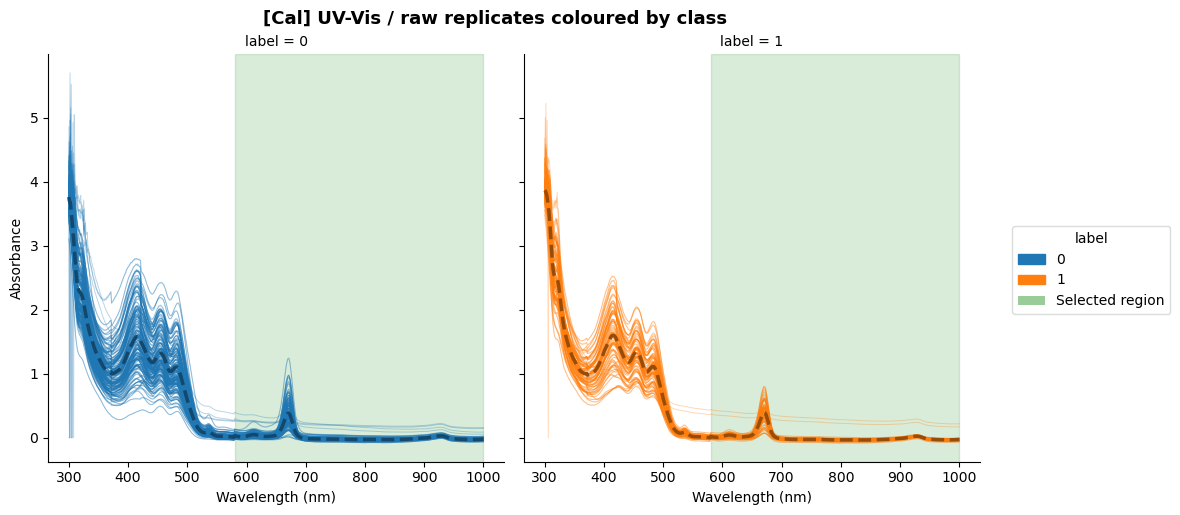

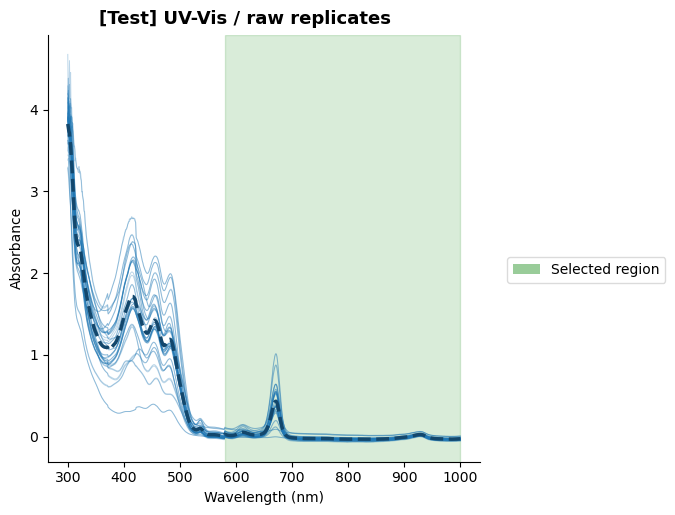

In [62]:
height = 5.0
aspect = 1.0

plot_spectra(
    data["cal_uvvis"],
    metadata=meta,
    color_by="label",
    facet_col_by="label",
    show_mean=True,
    regions=[(580, 1000)],
    xlabel="Wavelength (nm)",
    ylabel="Absorbance",
    title="[Cal] UV-Vis / raw replicates coloured by class",
    height=height,
    aspect=aspect,
)

plot_spectra(
    data["test_uvvis"],
    show_mean=True,
    regions=[(580, 1000)],
    xlabel="Wavelength (nm)",
    ylabel="Absorbance",
    title="[Test] UV-Vis / raw replicates",
    height=height,
    aspect=aspect,
)

## FTIR

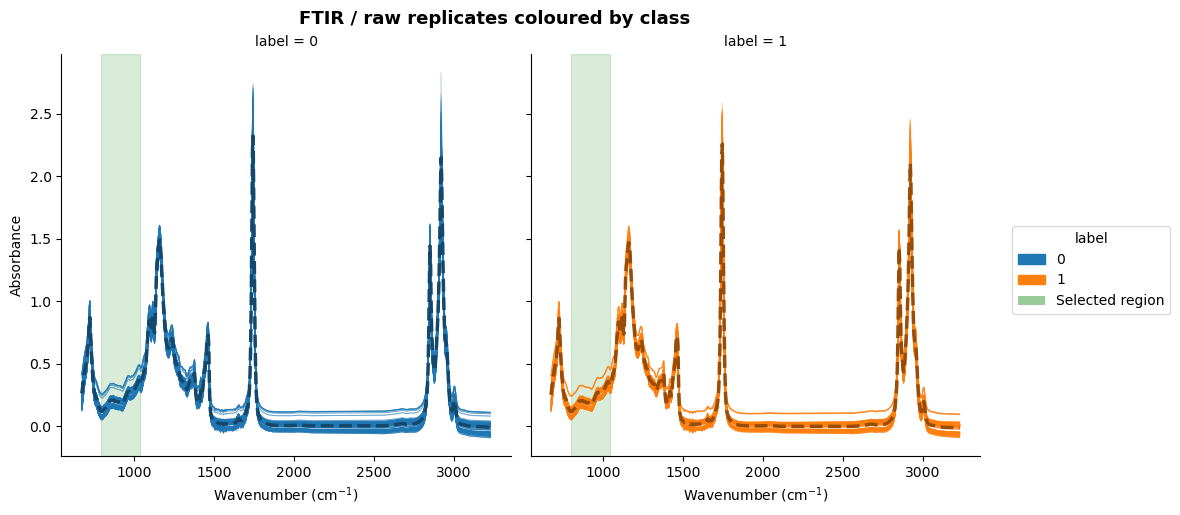

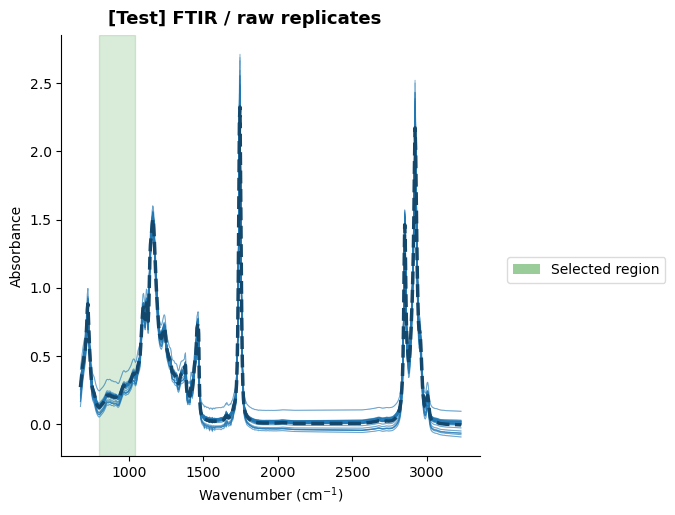

In [63]:
plot_spectra(
    data["cal_ftir"],
    metadata=meta,
    color_by="label",
    facet_col_by="label",
    show_mean=True,
    regions=[(1040, 795)],
    xlabel="Wavenumber (cm$^{-1}$)",
    ylabel="Absorbance",
    title="FTIR / raw replicates coloured by class",
    height=height,
    aspect=aspect,
)

plot_spectra(
    data["test_ftir"],
    show_mean=True,
    regions=[(1040, 795)],
    xlabel="Wavenumber (cm$^{-1}$)",
    ylabel="Absorbance",
    title="[Test] FTIR / raw replicates",
    height=height,
    aspect=aspect,
)

## HS-MS

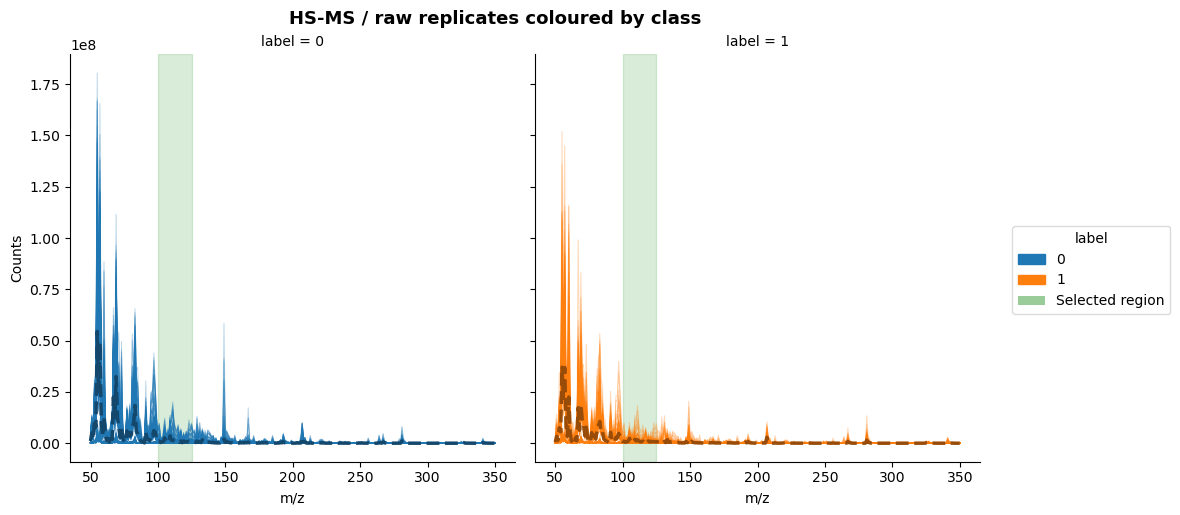

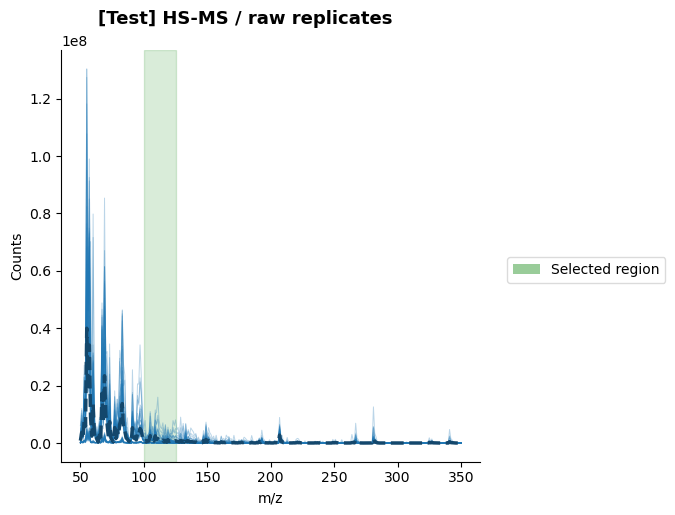

In [64]:
plot_spectra(
    data["cal_hsms"],
    metadata=meta,
    color_by="label",
    facet_col_by="label",
    regions=[(100, 125)],
    xlabel="m/z",
    ylabel="Counts",
    title="HS-MS / raw replicates coloured by class",
    height=height,
    aspect=aspect,
)

plot_spectra(
    data["test_hsms"],
    show_mean=True,
    regions=[(100, 125)],
    xlabel="m/z",
    ylabel="Counts",
    title="[Test] HS-MS / raw replicates",
    height=height,
    aspect=aspect,
)

# Preprocessed spectra plots

## UV-Vis

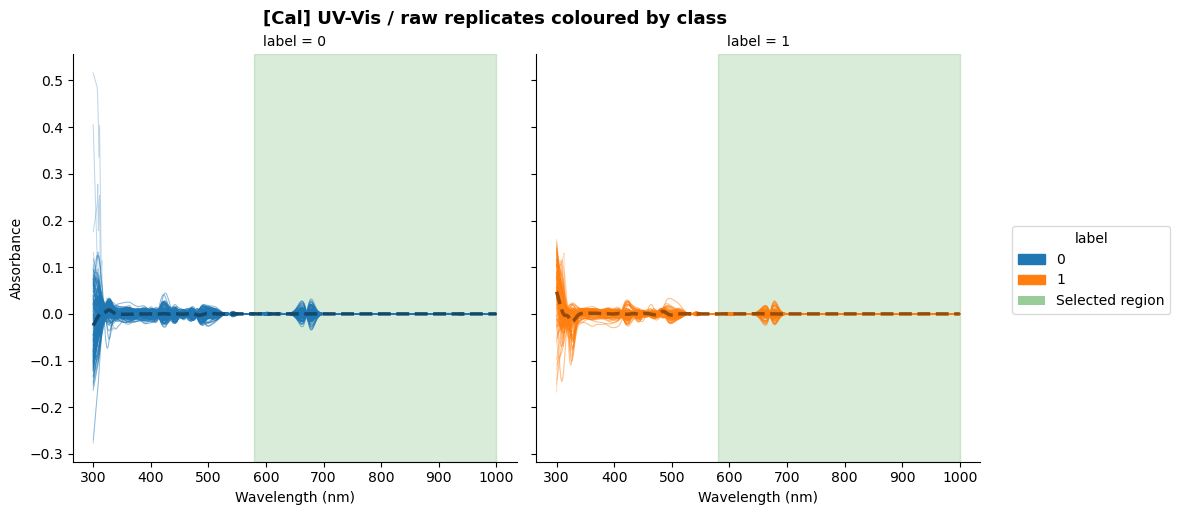

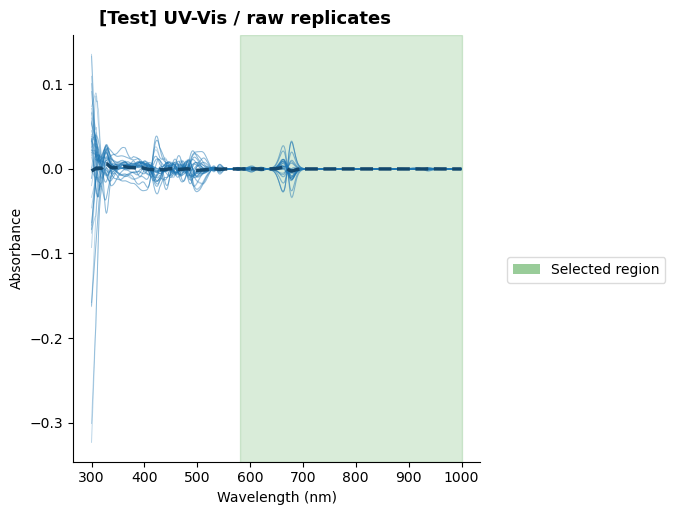

In [65]:
X_cal_uvvis = get_spectral_matrix(data["cal_uvvis"], average=False)
X_cal_uvvis = snv(X_cal_uvvis)
X_cal_uvvis = savgol_derivative(X_cal_uvvis)
X_cal_uvvis, X_cal_uvvis_centers = mean_center(X_cal_uvvis, center=None)

plot_spectra(
    X_cal_uvvis,
    metadata=meta,
    color_by="label",
    facet_col_by="label",
    regions=[(580, 1000)],
    xlabel="Wavelength (nm)",
    ylabel="Absorbance",
    title="[Cal] UV-Vis / raw replicates coloured by class",
    height=height,
    aspect=aspect,
)


X_test_uvvis = get_spectral_matrix(data["test_uvvis"], average=False)
X_test_uvvis = snv(X_test_uvvis)
X_test_uvvis = savgol_derivative(X_test_uvvis)
X_test_uvvis, _ = mean_center(X_test_uvvis, center=X_cal_uvvis_centers)

plot_spectra(
    X_test_uvvis,
    show_mean=True,
    regions=[(580, 1000)],
    xlabel="Wavelength (nm)",
    ylabel="Absorbance",
    title="[Test] UV-Vis / raw replicates",
    height=height,
    aspect=aspect,
)

## FTIR

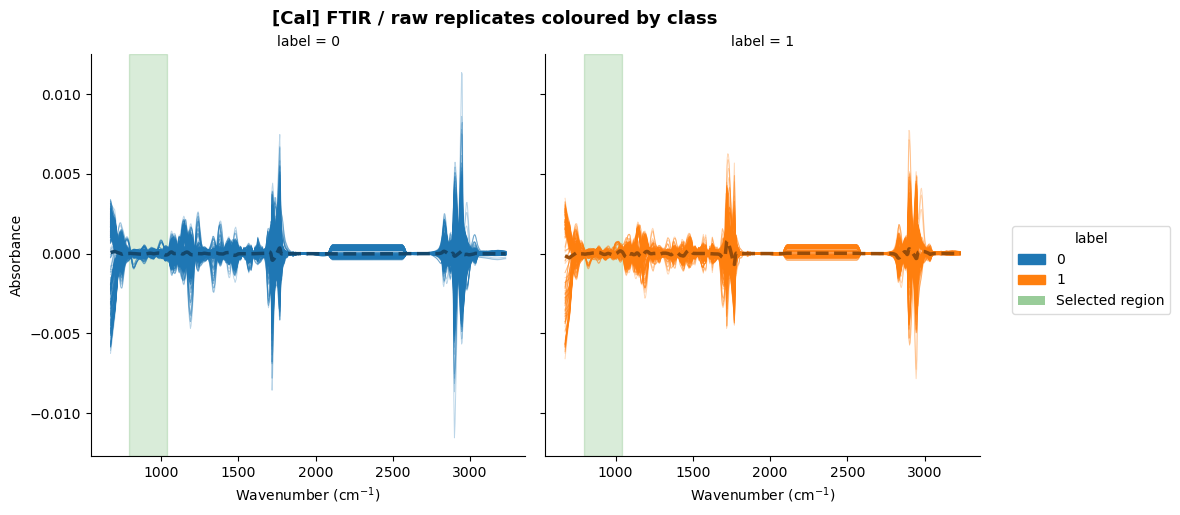

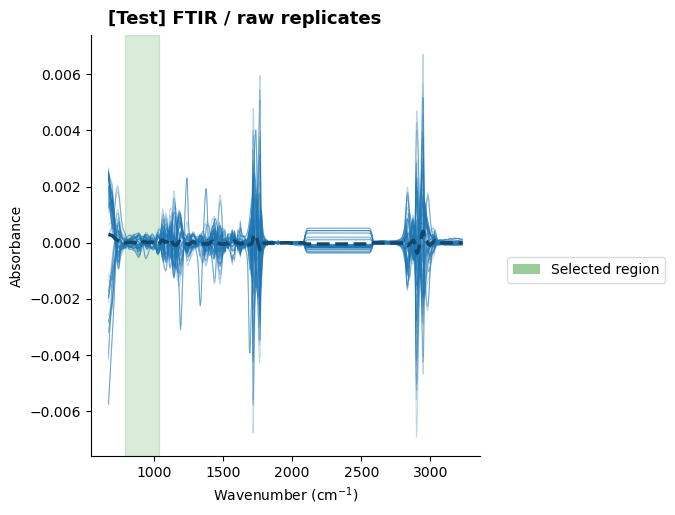

In [66]:
X_cal_ftir = get_spectral_matrix(data["cal_ftir"], average=False)
X_cal_ftir = snv(X_cal_ftir)
X_cal_ftir = savgol_derivative(X_cal_ftir)
X_cal_ftir, X_cal_ftir_centers = mean_center(X_cal_ftir, center=None)

plot_spectra(
    X_cal_ftir,
    metadata=meta,
    color_by="label",
    facet_col_by="label",
    regions=[(1040, 795)],
    xlabel="Wavenumber (cm$^{-1}$)",
    ylabel="Absorbance",
    title="[Cal] FTIR / raw replicates coloured by class",
    height=height,
    aspect=aspect,
)


X_test_ftir = get_spectral_matrix(data["test_ftir"], average=False)
X_test_ftir = snv(X_test_ftir)
X_test_ftir = savgol_derivative(X_test_ftir)
X_test_ftir, _ = mean_center(X_test_ftir, center=X_cal_ftir_centers)

plot_spectra(
    X_test_ftir,
    show_mean=True,
    regions=[(1040, 795)],
    xlabel="Wavenumber (cm$^{-1}$)",
    ylabel="Absorbance",
    title="[Test] FTIR / raw replicates",
    height=height,
    aspect=aspect,
)

## HS-MS

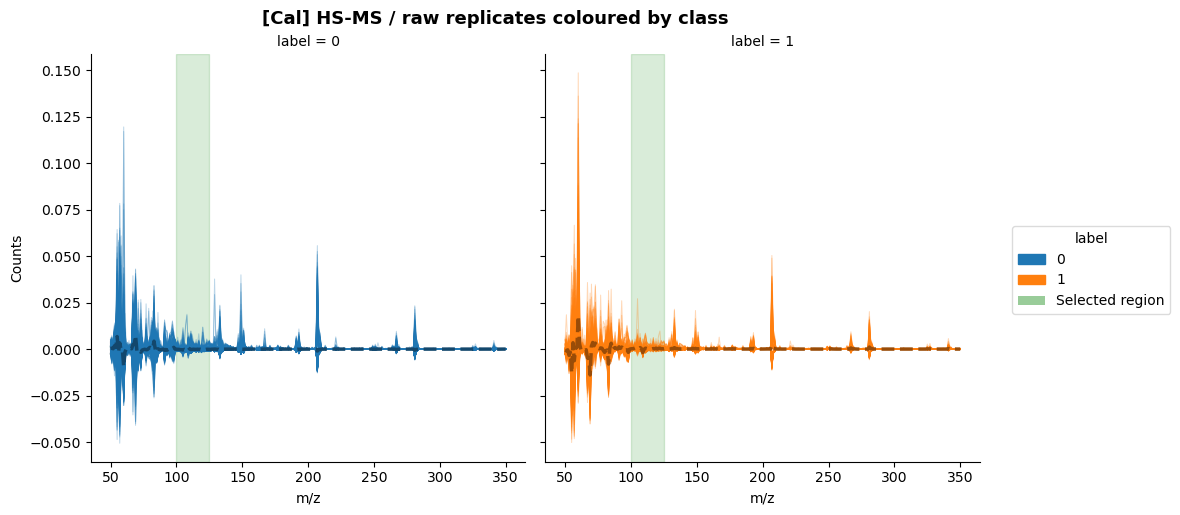

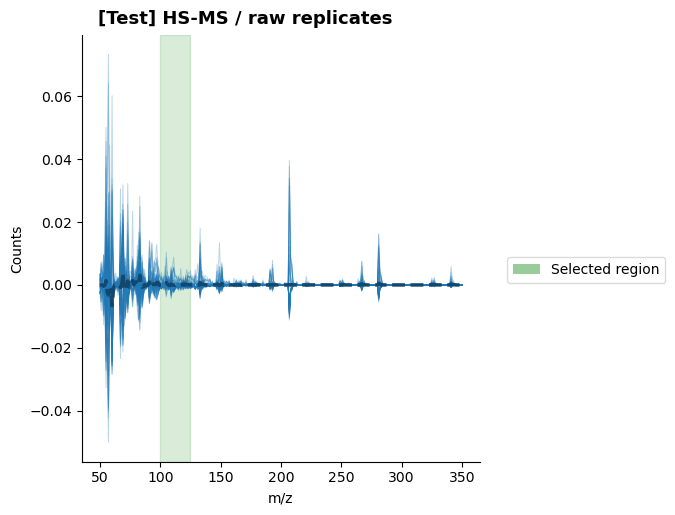

In [67]:
X_cal_hsms = get_spectral_matrix(data["cal_hsms"], average=False)
X_cal_hsms = row_profile(X_cal_hsms)
X_cal_hsms = log_transform(X_cal_hsms)
X_cal_hsms, X_cal_hsms_centers = mean_center(X_cal_hsms, center=None)

plot_spectra(
    X_cal_hsms,
    metadata=meta,
    color_by="label",
    facet_col_by="label",
    regions=[(100, 125)],
    xlabel="m/z",
    ylabel="Counts",
    title="[Cal] HS-MS / raw replicates coloured by class",
    height=height,
    aspect=aspect,
)


X_test_hsms = get_spectral_matrix(data["test_hsms"], average=False)
X_test_hsms = row_profile(X_test_hsms)
X_test_hsms = log_transform(X_test_hsms)
X_test_hsms, _ = mean_center(X_test_hsms, center=X_cal_hsms_centers)

plot_spectra(
    X_test_hsms,
    show_mean=True,
    regions=[(100, 125)],
    xlabel="m/z",
    ylabel="Counts",
    title="[Test] HS-MS / raw replicates",
    height=height,
    aspect=aspect,
)